In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

In [ ]:
X,_ = make_blobs(n_samples=300, centers=3, cluster_std=0.6,random_state=0)

In [ ]:
#Apply model
dbscan = DBSCAN(eps=0.8, min_samples=5)
label = dbscan.fit_predict(X)

In [ ]:
n_clusters = len(set(label)) - (1 if -1 in label else 0)
n_clusters

2

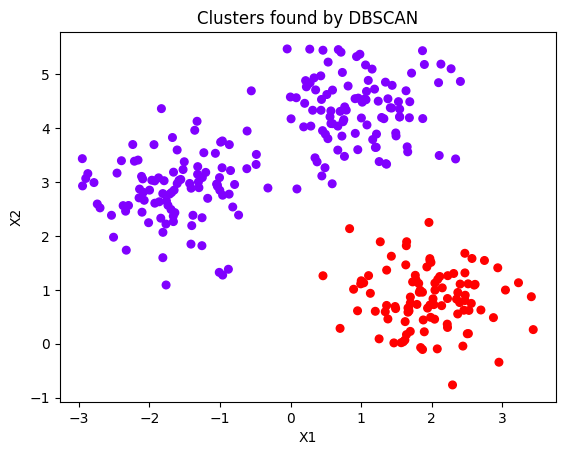

In [ ]:
plt.scatter(X[:,0], X[:,1], c=label, cmap='rainbow', s=30)
plt.title('Clusters found by DBSCAN')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Ex: 2

In [ ]:
import numpy as np

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [ ]:
X,_ = make_moons(n_samples=300, noise=0.025, random_state=42)

In [ ]:
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels = dbscan.fit_predict(X)

In [ ]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters

2

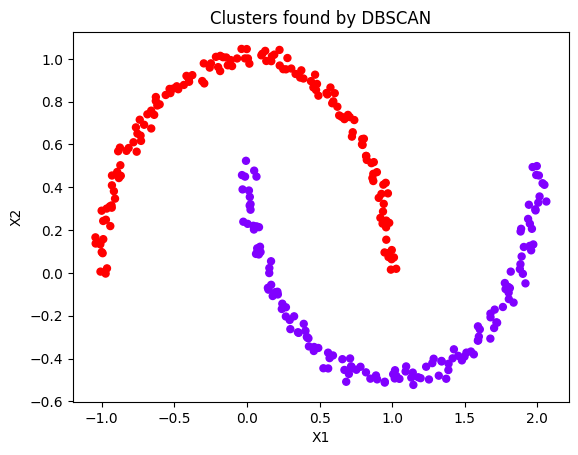

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow', s=25)
plt.title('Clusters found by DBSCAN')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Ex 3:

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

In [ ]:
X,_ = make_blobs(n_samples = 500, centers=4, cluster_std=[0.4,0.6,0.5,0.7], random_state=42)

In [ ]:
#Adding noise
noise = np.random.uniform(low=-10, high=10, size=(50,2))
X = np.vstack((X,noise))

In [ ]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
labels = dbscan.fit_predict(X)

In [ ]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

In [ ]:
print(n_clusters)
print(n_noise)

4
48


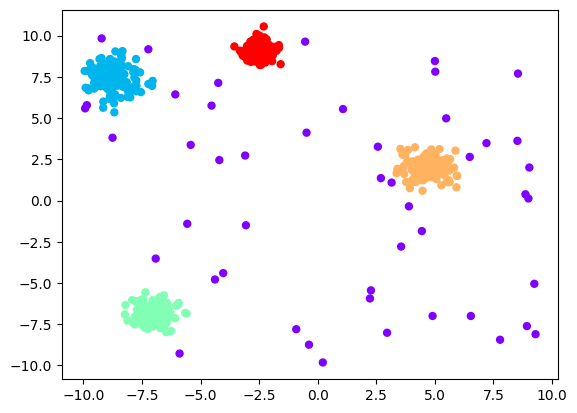

In [ ]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow', s=25)

**Ex:4 City Lifestyle Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("/content/city_lifestyle_dataset.csv")
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [ ]:
df.shape

(300, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [ ]:
df.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


In [ ]:
#Feature selection
X = df.drop(columns=['city_name',	'country'])
#

In [ ]:
X

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...
295,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,836,3910,98.7,1340,40,55.7,8.5,38.6
298,758,3490,91.2,1390,36,54.1,8.5,44.6


In [ ]:
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [ ]:
# Kmeans algorithm
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_sc)

In [ ]:
kmeans_sc = silhouette_score(X_sc, df['kmeans_cluster'])
kmeans_sc

np.float64(0.2238576158318568)

In [ ]:
#Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_sc)

In [ ]:
db_labels = df['dbscan_cluster']

# Remove noise (-1)
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
  dbscan_sc = silhouette_score(X_sc[mask], db_labels[mask])
else:
  dbscan_sc = "Not valid score"


In [ ]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

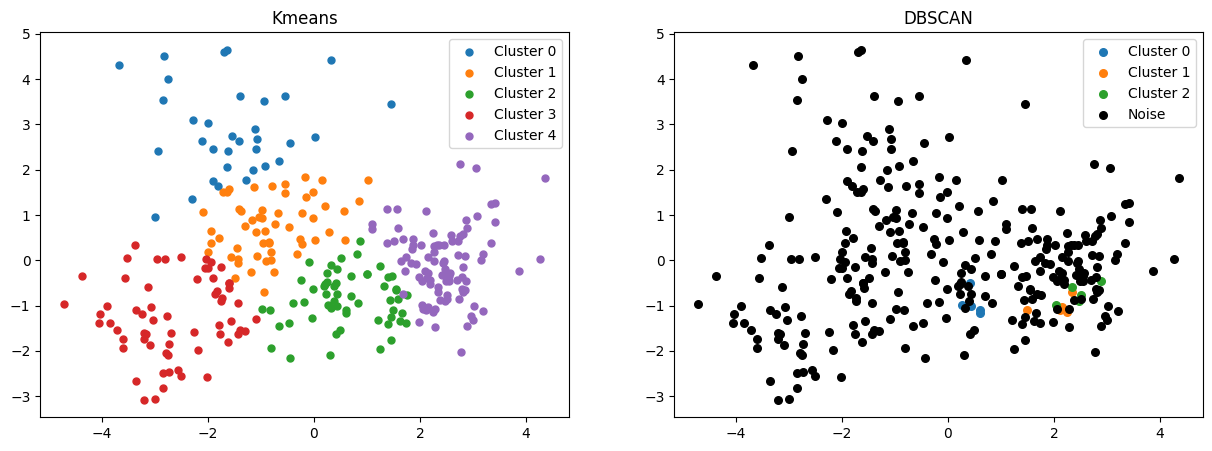

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
for cluster in set(df["kmeans_cluster"]):
  mask_k = df["kmeans_cluster"] == cluster
  plt.scatter(X_pca[mask_k, 0], X_pca[mask_k, 1], label = f"Cluster {cluster}", s=25)
  plt.legend()
plt.title("Kmeans")

plt.subplot(1,2,2)
for cluster in set(df["dbscan_cluster"]):
  mask_d = df["dbscan_cluster"] == cluster

  if cluster == -1:
    label = "Noise"
    color = "black"
  else:
    label = f"Cluster {cluster}"
    color = None

  plt.scatter(X_pca[mask_d,0], X_pca[mask_d, 1], label=label,s=30, c=color)
  plt.legend()
plt.title("DBSCAN")
plt.show()

EX: PCA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Dataset
np.random.seed(42)
n = 100

In [ ]:
A = np.random.normal(0,1,n)
B = 2*A + np.random.normal(0, 0.5, n)
C = -A + np.random.normal(0, 0.3, n)

In [ ]:
data = pd.DataFrame({'A':A, 'B':B, 'C':C})
data.head()

,A,B,C
0,0.496714,0.285743,-0.389378
1,-0.138264,-0.486851,0.306500
2,0.647689,1.124020,-0.322773
3,1.523030,2.644921,-1.206889
4,-0.234153,-0.548950,-0.179147


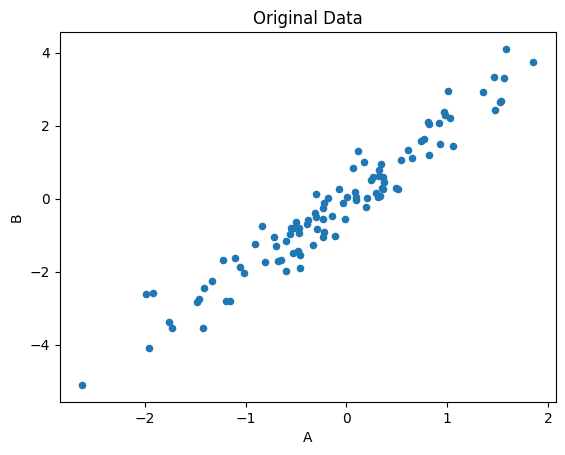

In [ ]:
plt.scatter(data['A'], data['B'], s=20)
plt.title('Original Data')
plt.xlabel('A')
plt.ylabel('B')
plt.show()

In [ ]:
sc = StandardScaler()
X_sc = sc.fit_transform(data)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

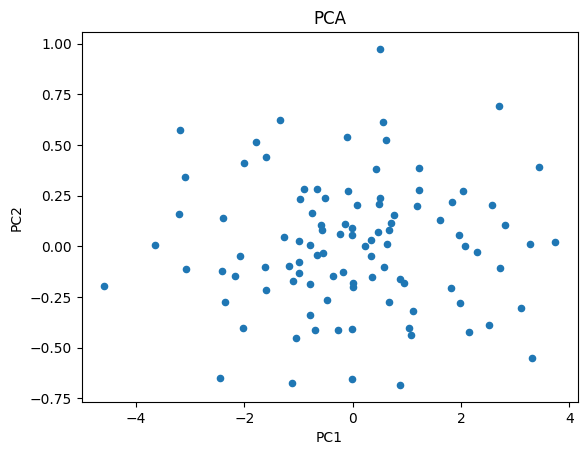

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=20)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
pca.explained_variance_ratio_

array([0.956829  , 0.03336233])

Ex: PCA in detail

In [ ]:
# Step 1 : Original matrix
X = np.array([[2,3],[3,5],[4,7]])
X

array([[2, 3],
       [3, 5],
       [4, 7]])

In [ ]:
# Step 2 : Mean centering

mean = np.mean(X, axis=0)
mean

array([3., 5.])

In [ ]:
#Centered mean
X_mean = X-mean
X_mean

array([[-1., -2.],
       [ 0.,  0.],
       [ 1.,  2.]])

In [ ]:
# Step 3 : Covariance3 matrix
cov =np.cov(X_mean, rowvar=False)
cov

array([[1., 2.],
       [2., 4.]])

In [ ]:
# Step 4 : Eigen vector and Eigen value

eigenvalues, eigenvectors = np.linalg.eigh(cov)

In [ ]:
print(eigenvalues)
print(eigenvectors)

[0. 5.]
[[-0.89442719  0.4472136 ]
 [ 0.4472136   0.89442719]]


In [ ]:
# Step 5: Sort Eigen values and vectors
sorted_val = np.argsort(eigenvalues)[::-1]

In [ ]:
# Rearrange
eigenvalues = eigenvalues[sorted_val]
eigenvectors = eigenvectors[:, sorted_val]

In [ ]:
# Step 6 : Select PC1
top_vector = eigenvectors[:, 0]
top_vector

array([0.4472136 , 0.89442719])

In [ ]:
# Step 7 : Projection
z = X_mean.dot(top_vector)
z

array([-2.23606798,  0.        ,  2.23606798])

In [ ]:
# Answers:
print("1. Original data=", X)
print("2. Mean=", mean)
print("3. Centered mean=", X_mean)
print("4. Covariance=", cov)
print("5. Eigenvalues=", eigenvalues)
print("6. Eigenvectors=", eigenvectors)
print("7. Top vector=", top_vector)
print("8. Projection=", z)

1. Original data= [[2 3]
 [3 5]
 [4 7]]
2. Mean= [3. 5.]
3. Centered mean= [[-1. -2.]
 [ 0.  0.]
 [ 1.  2.]]
4. Covariance= [[1. 2.]
 [2. 4.]]
5. Eigenvalues= [5. 0.]
6. Eigenvectors= [[ 0.4472136  -0.89442719]
 [ 0.89442719  0.4472136 ]]
7. Top vector= [0.4472136  0.89442719]
8. Projection= [-2.23606798  0.          2.23606798]


EX: PCA

In [51]:
from sklearn.datasets import load_wine

In [52]:
data = load_wine()

In [53]:
X = data.data
y = data.target

In [54]:
df = pd.DataFrame(X, columns=data.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [56]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [57]:
# Do preprocessing
# Do EDA

# apply standardization
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [59]:
X_sc.shape

(178, 13)

In [60]:
# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

In [61]:
X_pca.shape

(178, 2)

In [62]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 ])

In [64]:
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df['target'] = y

X_pca_df.head()


,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


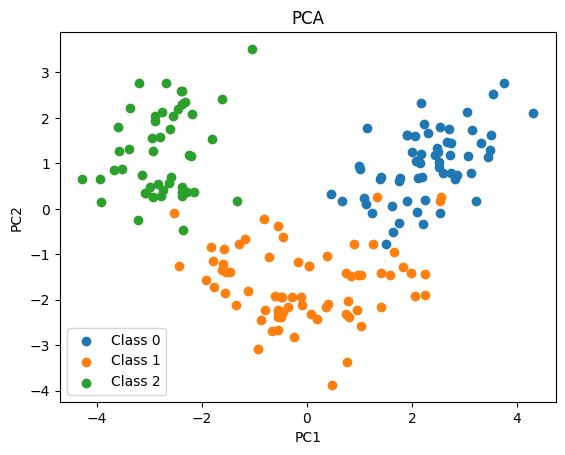

In [66]:
for label in np.unique(y):
    plt.scatter(
        X_pca_df[X_pca_df["target"] == label]["PC1"],
        X_pca_df[X_pca_df["target"] == label]["PC2"],
        label=f"Class {label}"
    )
plt.legend()
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()